# Bagging Regressor — Ensemble Learning
**Bagging** (short for **Bootstrap Aggregating**) is an ensemble technique where we train multiple copies of the same model on different random subsets of the training data, then average their predictions to get a final result.

Think of it like asking 500 different people to estimate the price of a house, each of whom has seen a slightly different set of historical sales. Their average estimate is likely to be far more reliable than any single person's guess.

### The core idea :
1. Take the original training dataset.
2. Draw random samples from it **with replacement** — this is called *bootstrapping*.
3. Train a separate model on each bootstrap sample.
4. For regression, **average** all predictions to produce the final output.

### Why does this help?
A single decision tree tends to overfit — it memorizes the training data too well and performs poorly on new data. Bagging reduces this overfitting by introducing randomness and then averaging out the noise across many trees.

---

## Dataset: Boston Housing

Use the **Boston Housing dataset**, which contains information about housing in the Boston area. The goal is to predict **`medv`** — the median value of owner-occupied homes (in thousands of dollars).

| Column | Description |
|--------|-------------|
| `crim`     | Per capita crime rate by town |
| `zn`       | Proportion of residential land zoned for lots over 25,000 sq. ft. |
| `indus` | Proportion of non-retail business acres per town |
| `chas` | Charles River dummy variable (1 if tract bounds river; 0 otherwise) |
| `nox` | Nitric oxide concentration (parts per 10 million) |
| `rm` | Average number of rooms per dwelling |
| `age` | Proportion of owner-occupied units built before 1940 |
| `dis` | Weighted distances to five Boston employment centres |
| `rad` | Index of accessibility to radial highways |
| `tax` | Full-value property-tax rate per 10,000 |
| `ptratio` | Pupil-teacher ratio by town |
| `b` | Proportion of residents of African-American descent |
| `lstat` | Percentage of lower status population |
| `medv` | Target: median home value in $1000s |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import BaggingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

### Load and Inspect the Data

In [3]:
data = pd.read_csv("BostonHousing.csv")
data.head(2)

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.9,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.9,9.14,21.6


In [5]:
X = data.drop(columns=['medv'])
y = data['medv']

print(f"Dataset shape  : {X.shape}")
print(f"Target range   : [{y.min():.2f}, {y.max():.2f}]")
print(f"Target mean    : {y.mean():.4f}")
print(f"Target std     : {y.std():.4f}")
print()
print("Feature summary:")
X.describe().T[['mean', 'std', 'min', 'max']]

Dataset shape  : (506, 13)
Target range   : [5.00, 50.00]
Target mean    : 22.5328
Target std     : 9.1971

Feature summary:


,mean,std,min,max
crim,3.613524,8.601545,0.00632,88.9762
zn,11.363636,23.322453,0.00000,100.0000
indus,11.136779,6.860353,0.46000,27.7400
chas,0.069170,0.253994,0.00000,1.0000
nox,0.554695,0.115878,0.38500,0.8710
rm,6.284634,0.702617,3.56100,8.7800
age,68.574901,28.148861,2.90000,100.0000
dis,3.795043,2.105710,1.12960,12.1265
rad,9.549407,8.707259,1.00000,24.0000
tax,408.237154,168.537116,187.00000,711.0000


---
### Visualize the target distribution

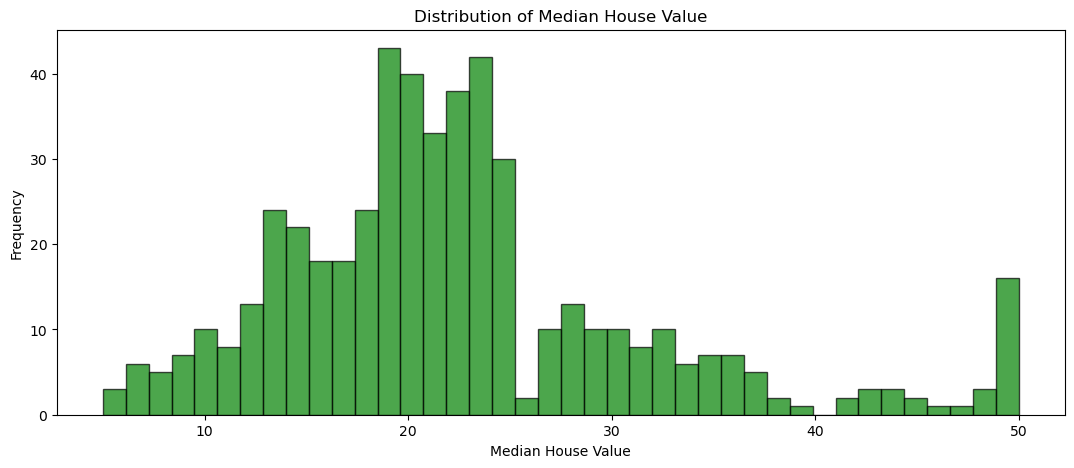

In [8]:
plt.figure(figsize=(13, 5))
plt.hist(y, bins=40, edgecolor='black', alpha=0.7,color='green')
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

### Correlation heatmap between features

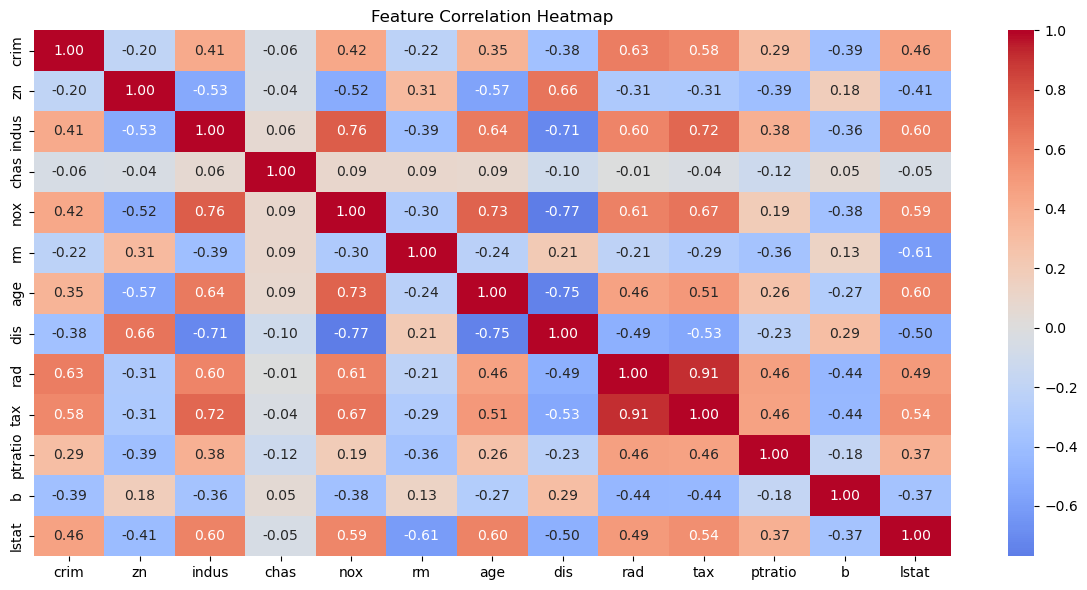

In [11]:
plt.figure(figsize=(12,6))
correlation_matrix = X.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

---
### Train-Test Split

Reserve 20% of the data as a **test set** — rows the model will never see during training. This lets us evaluate how well the model generalizes to new, unseen data.

- `test_size=0.2` means 80% of rows go to training, 20% to testing
- `random_state=42` fixes the random seed so results are reproducible

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42)

### Feature Scaling

In [16]:
scale = StandardScaler()
scale.fit(X_train)
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)

---
## Part A — Baseline Models (Without Bagging)

Before applying bagging, train four standard regression models on their own:

| Model | How it works (briefly) |
|-------|------------------------|
| **KNN Regressor** | Finds the k nearest training samples and averages their values |
| **Decision Tree Regressor** | Learns a tree of if-else rules to split data into regions with similar values |
| **SVR (Support Vector Regressor)** | Fits a line/curve that stays within a margin of the true values |
| **Linear Regression** | Fits a straight-line relationship between features and the target |


In [18]:
knn = KNeighborsRegressor()
decision_tree = DecisionTreeRegressor()
svr = SVR()
linear_reg = LinearRegression()

knn.fit(X_train,y_train)
decision_tree.fit(X_train,y_train)
svr.fit(X_train,y_train)
linear_reg.fit(X_train , y_train)

y_pred1 = knn.predict(X_test)
y_pred2 = decision_tree.predict(X_test)
y_pred3 = svr.predict(X_test)
y_pred4 = linear_reg.predict(X_test)

print("R^2 score for KNN ::",round(r2_score(y_test,y_pred1),2))
print("R^2 score for Decision Tree ::",round(r2_score(y_test,y_pred2),2))
print("R^2 score for SVR ::",round(r2_score(y_test,y_pred3),2))
print("R^2 score for Linear Regresion ::",round(r2_score(y_test,y_pred4),2))

R^2 score for KNN :: 0.72
R^2 score for Decision Tree :: 0.87
R^2 score for SVR :: 0.65
R^2 score for Linear Regresion :: 0.67


---

## Part B — BaggingRegressor

Apply bagging by wrapping a Decision Tree. Instead of training one tree, we train **500 trees**, each on a different random subset of the data.

### Key parameters ::

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `estimator` | `DecisionTreeRegressor()` | The base model to replicate — we chose a decision tree |
| `n_estimators` | `500` | Number of trees to train in the ensemble |
| `max_samples` | `0.6` | Each tree trains on 60% of the training rows (sampled randomly) |
| `max_features` | `1.0` | Each tree uses 100% of the features (all columns) |
| `bootstrap` | `True` | Sampling is done **with replacement** — the same row can be picked multiple times |
| `random_state` | `42` | Fixes randomness so results are reproducible |

With `max_samples=0.6`, each of the 500 trees sees a different 60% slice of the training data. This ensures diversity among the trees, which is what makes the ensemble powerful.

In [20]:
bag_regressor = BaggingRegressor(
                    estimator = DecisionTreeRegressor(),
                    n_estimators=500,
                    max_samples=0.6,
                    max_features=1.0,
                    bootstrap=True,
                    random_state=42
                   )

bag_regressor.fit(X_train, y_train)
y_pred = bag_regressor.predict(X_test)
print("R^2 Score For Bagging Regressor :: ",round(r2_score(y_test,y_pred),2))

R^2 Score For Bagging Regressor ::  0.87


---
### Hyperparameter Tuning with GridSearchCV

In [22]:
%%time
params = {
    'estimator': [
        DecisionTreeRegressor(random_state=1),
        LinearRegression(),
        KNeighborsRegressor()],
    'n_estimators': [100, 500],
    'max_samples': [0.5, 1.0],
    'max_features': [0.5, 1.0],
    'bootstrap': [True,False],
    'bootstrap_features': [True,False]
}
bag = BaggingRegressor(
    random_state = 1,
    n_jobs = -1
)
bagging_regressor_grid = GridSearchCV(
    estimator = bag,
    param_grid = params,
    cv = 3,
    scoring = 'r2',
    n_jobs = -1,
    verbose = 1
)
bagging_regressor_grid.fit(X_train, y_train)
print(f"Train R² Score : {bagging_regressor_grid.best_estimator_.score(X_train, y_train):.3f}")
print(f"Test  R² Score : {bagging_regressor_grid.best_estimator_.score(X_test, y_test):.3f}")
print(f"Best CV R² Score : {bagging_regressor_grid.best_score_:.3f}")
print("Best Parameters :", bagging_regressor_grid.best_params_)

Fitting 3 folds for each of 96 candidates, totalling 288 fits
Train R² Score : 0.976
Test  R² Score : 0.858
Best CV R² Score : 0.815
Best Parameters : {'bootstrap': True, 'bootstrap_features': True, 'estimator': DecisionTreeRegressor(random_state=1), 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 100}
CPU times: total: 3.77 s
Wall time: 4min 44s


### Final Model Using Best Parameters from GridSearchCV

In [25]:
bag_regressor = BaggingRegressor(
     bootstrap =  True,
     bootstrap_features = True, 
     estimator =  DecisionTreeRegressor(random_state=1),
     max_features =  1.0,
     max_samples = 1.0, 
     n_estimators =  100
    )

bag_regressor.fit(X_train, y_train)
y_pred = bag_regressor.predict(X_test)
print("R^2 Score For Bagging Regressor [ According to GridsearcCV ] :: ",round(r2_score(y_test,y_pred),2))

R^2 Score For Bagging Regressor [ According to GridsearcCV ] ::  0.85


In [ ]:
importances = bag_regressor.feature_importances_
# Create sorted pairs
sorted_idx = np.argsort(importances)
plt.figure(figsize=(10, 5))
plt.barh(np.array(feature_names)[sorted_idx], importances[sorted_idx])
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.show()